# Starburst99: Stellar Population Synthesis

This notebook demonstrates the `pyathena.util.sb99` module, which reads and
analyses output from the [Starburst99](https://www.stsci.edu/science/starburst99/)
stellar population synthesis code.

We use a solar-metallicity ($Z = 0.014$), instantaneous-burst cluster of
$10^6\,M_\odot$ with log-spaced time outputs from 0.1 to 100 Myr
(Geneva tracks, no rotation).

**Topics covered:**
1. Loading SB99 data
2. SED evolution
3. Band-integrated luminosities and momentum injection rates
4. Dust cross sections and mean photon energies vs age
5. Supernova and stellar wind feedback

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as au
import astropy.constants as ac

import pyathena as pa
from pyathena.util import sb99
from pyathena.plt_tools.set_plt import set_plt_fancy

set_plt_fancy()

# Path to the bundled SB99 dataset
import pathlib
REPO = pathlib.Path(pa.__file__).parent.parent
BASEDIR = REPO / 'data' / 'sb99' / 'Z014_M1E6_GenevaV00_logdt'

## 1. Load SB99 data

`SB99` discovers the output files automatically from the directory.

In [2]:
sb = sb99.SB99(str(BASEDIR))

rr = sb.read_rad()    # spectrum + derived radiation quantities
rw = sb.read_wind()   # stellar wind power and momentum
rs = sb.read_sn()     # supernova rate and energy

print('Time range: {:.2f} – {:.1f} Myr  ({} steps)'.format(
    rr['time_Myr'][0], rr['time_Myr'][-1], len(rr['time_Myr'])))
print('Wavelength range: {} – {} Å  ({} points)'.format(
    rr['wav'].min(), rr['wav'].max(), len(rr['wav'])))
print('Band luminosity keys:', list(rr['L'].keys()))

[SB99] Fixed mass ; logM: 6.0


Time range: 0.11 – 99.9 Myr  (75 steps)
Wavelength range: 91.0 – 1600000.0 Å  (1221 points)
Band luminosity keys: ['tot', 'LyC', 'LW', 'PE', 'OPT', 'IR', 'FUV', 'UV']


## 2. SED evolution

Plot $L_\lambda / M_*$ as a function of wavelength at different ages,
color-coded from blue (young) to red (old).
Grey bands indicate the LyC ($<912\,\text{Å}$), LW ($912$–$1108\,\text{Å}$),
and PE ($1108$–$2068\,\text{Å}$) bands.

0.1 0.4 0.7 1.0 1.3 1.6 2.0 2.5 3.0 3.8 4.6 5.7 7.0 8.7 10.7 13.2 16.3 20.1 24.8 30.5 37.6 46.4 

/Users/jgkim/Dropbox/Projects/pyathena/pyathena/util/sb99.py:644: RuntimeWarning: divide by zero encountered in divide
  return 1.0/(ac.h.cgs.value*ac.c.cgs.value/1e-8/(1.0*au.eV).cgs.value)/x


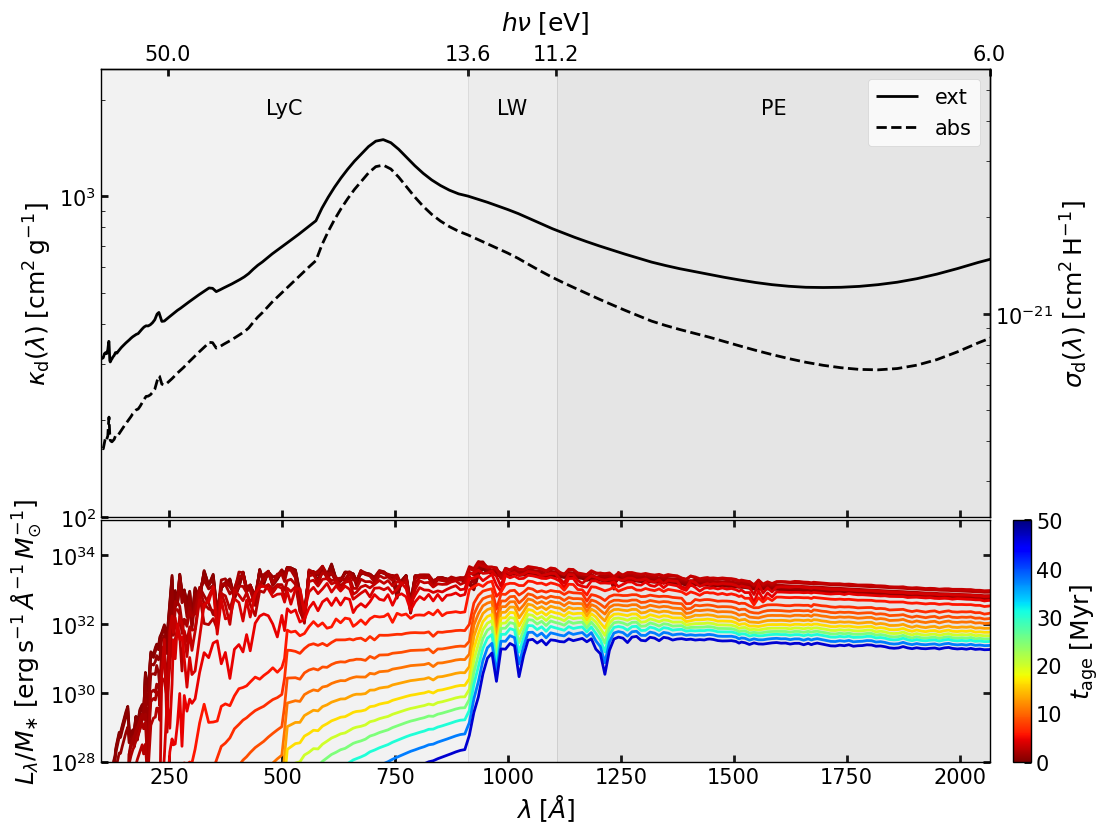

In [3]:
fig = sb.plt_spec_sigmad(rr, tmax=50.0, nstride=3, plt_isrf=False)

## 3. Band-integrated luminosity and momentum vs age

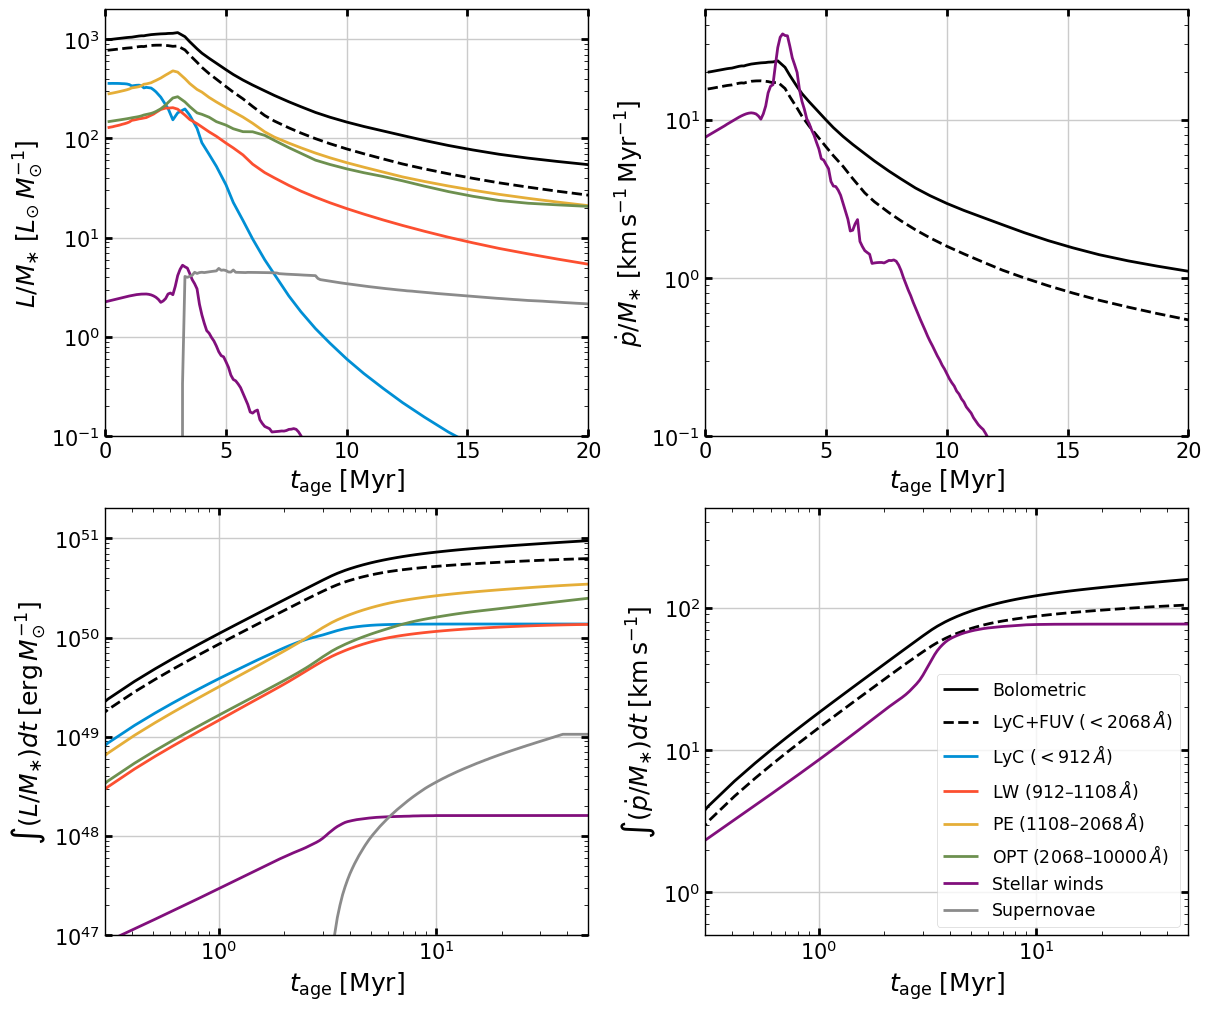

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True,
                         gridspec_kw=dict(height_ratios=[0.5, 0.5]))
axes = axes.flatten()

sb.plt_lum_evol(axes[0], rr, rw, rs, plt_sn=True)
sb.plt_pdot_evol(axes[1], rr, rw, rs)
sb.plt_lum_cumul(axes[2], rr, rw, rs, normed=False, plt_sn=True)
sb.plt_pdot_cumul(axes[3], rr, rw, rs, normed=False)

for ax in axes:
    ax.grid()

import matplotlib as mpl
plt.legend(
    [mpl.lines.Line2D([0],[0],c='k'),
     mpl.lines.Line2D([0],[0],c='k',ls='--'),
     mpl.lines.Line2D([0],[0],c='C0'),
     mpl.lines.Line2D([0],[0],c='C1'),
     mpl.lines.Line2D([0],[0],c='C2'),
     mpl.lines.Line2D([0],[0],c='C3'),
     mpl.lines.Line2D([0],[0],c='C7'),
     mpl.lines.Line2D([0],[0],c='C8')],
    ['Bolometric', r'LyC+FUV ($<2068\,\AA$)',
     r'LyC ($<912\,\AA$)', r'LW ($912$–$1108\,\AA$)',
     r'PE ($1108$–$2068\,\AA$)', r'OPT ($2068$–$10000\,\AA$)',
     'Stellar winds', 'Supernovae'],
    loc=4, fontsize='small')

plt.show()

### Luminosity-weighted timescales

The luminosity-weighted decay timescale $t_{\rm decay} = \int L\,t\,dt / \int L\,dt$
and the times by which 50% and 90% of the cumulative energy has been emitted.

In [5]:
print('{:<6s}  {:>12s}  {:>14s}  {:>14s}'.format(
    'Band', 't_decay (Myr)', 't_cumul_50 (Myr)', 't_cumul_90 (Myr)'))
print('-' * 52)
for k in ['LyC', 'LW', 'PE', 'FUV', 'OPT', 'tot']:
    print('{:<6s}  {:>12.1f}  {:>14.1f}  {:>14.1f}'.format(
        k,
        rr['tdecay_lum'][k],
        rr['tcumul_lum_50'][k],
        rr['tcumul_lum_90'][k]))

Band    t_decay (Myr)  t_cumul_50 (Myr)  t_cumul_90 (Myr)
----------------------------------------------------
LyC              2.0             1.3             3.0
LW               6.8             2.0             5.3
PE              12.0             2.1             6.1
FUV             10.5             2.1             5.7
OPT             20.8             2.5             8.7
tot             13.1             1.9             5.7


## 4. Dust cross sections and mean photon energies vs age

Luminosity-weighted mean dust extinction/absorption cross section per H atom
($\langle \sigma_d \rangle$), photoionization cross sections for H and H$_2$
($\langle \sigma_{\rm pi} \rangle$), and mean photon energies ($\langle h\nu \rangle$)
as a function of stellar age for each radiation band.

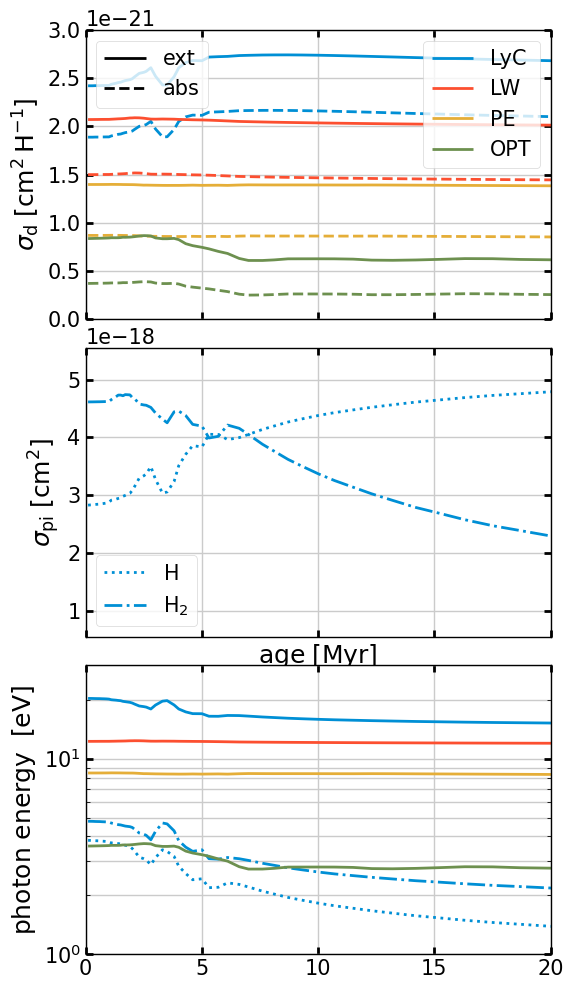

In [6]:
fig = sb99.plt_cross_sections_hnu(rr)

### Time-averaged values (first 20 Myr)

Print luminosity- and photon-rate-weighted averages of cross sections
and mean photon energies over the first 20 Myr.

In [7]:
sb99.print_lum_weighted_avg_quantities(rr, tmax=20.0)

Luminosity-weighted timescale int t*L dt/int L dt: {'tot': 13.083626516302827, 'LyC': 1.9961825896809684, 'LW': 6.765352460231709, 'PE': 11.95561901730297, 'OPT': 20.793501402349506, 'IR': 26.095059771217166, 'FUV': 10.520443645306552, 'UV': 8.722174870353681}
Bolometric at t=0: 988.0614641396108 1165.8656320873888 3.01
Bolometric at maximum: 1165.8656320873888
Time at maximum of Bolometric: 3.01
Lyman Continuum
- 50% of LyC photons are emitted in the first 1.31 Myr
- 90% of LyC photons are emitted in the first 3.01 Myr
- 95% of LyC photons are emitted in the first 3.81 Myr
- 50% of the initial value at 2.81 Myr
FUV (LW+PE)
- 50% of FUV photons are emitted in the first 2.11 Myr
- 90% of FUV photons are emitted in the first 5.71 Myr
- 95% of FUV photons are emitted in the first 8.71 Myr
- 50% of the initial value at 6.11 Myr
LyC :
Cabs Cext Crpr hnu : 1.93e-21, 2.47e-21, 2.08e-21 1.97e+01
sigma_pi_H dhnu_H 3.01e-18, 3.57e+00
sigma_pi_H2 dhnu_H2 4.61e-18, 4.55e+00
LW :
Cabs Cext Crpr hnu

## 5. Supernova and wind feedback

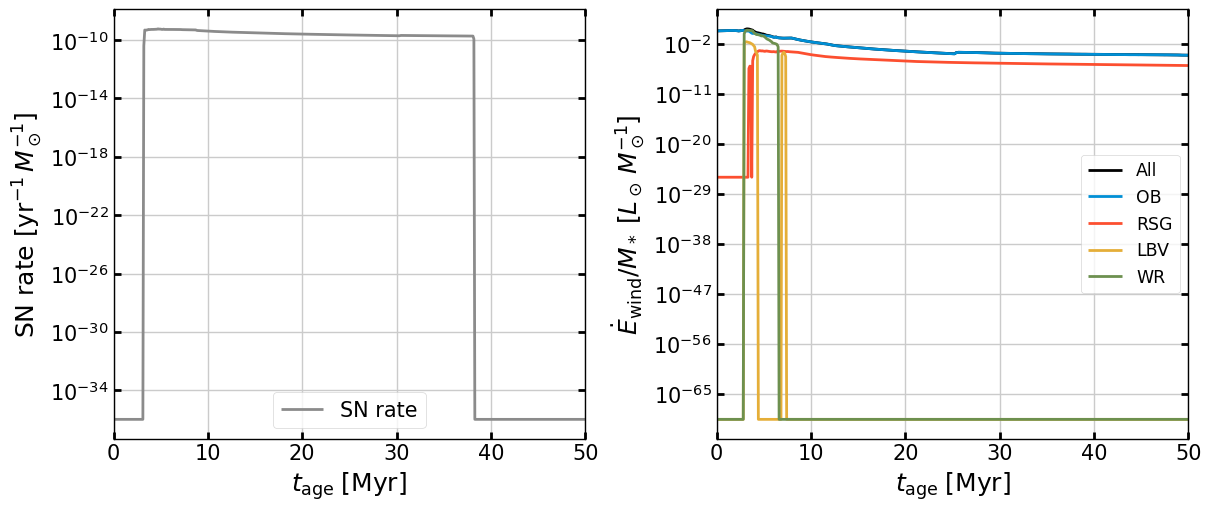

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# SN rate
ax = axes[0]
ax.semilogy(rs['time_Myr'], rs['SN_rate'], c='C8', label='SN rate')
ax.set_xlabel(r'$t_{\rm age}\;[{\rm Myr}]$')
ax.set_ylabel(r'SN rate $[{\rm yr}^{-1}\,M_\odot^{-1}]$')
ax.set_xlim(0, 50)
ax.grid()
ax.legend()

# Wind energy injection rate
ax = axes[1]
Lsun = ac.L_sun.cgs.value
for v, c, label in [('all','k','All'), ('OB','C0','OB'),
                    ('RSG','C1','RSG'), ('LBV','C2','LBV'), ('WR','C3','WR')]:
    ax.semilogy(rw['time_Myr'], rw[f'Edot_{v}']/Lsun,
                c=c, label=label)
ax.set_xlabel(r'$t_{\rm age}\;[{\rm Myr}]$')
ax.set_ylabel(r'$\dot{E}_{\rm wind}/M_*\;[L_\odot\,M_\odot^{-1}]$')
ax.set_xlim(0, 50)
ax.grid()
ax.legend(fontsize='small')

plt.show()